In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
df = pd.concat([
    pd.read_csv("Output1.csv"),
    pd.read_csv("output2.csv"),
    pd.read_csv("output3.csv")
], ignore_index=True)

In [9]:
df.columns = df.columns.str.strip()

In [10]:
# --- Keep only numeric features ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_mal = df[num_cols].fillna(0).copy()
df_mal['label'] = 1   # Spyware = 1

In [11]:
# --- Generate synthetic benign rows ---
np.random.seed(42)
n = len(df_mal)
benign_data = {}
for col in num_cols:
    col_min = df_mal[col].min()
    col_max = df_mal[col].max()
    # Benign samples have lower/different values than malware
    benign_data[col] = np.random.uniform(col_min * 0.1, col_max * 0.4, size=n)

In [13]:
df_ben = pd.DataFrame(benign_data)
df_ben['label'] = 0   # Benign = 0

In [14]:
# --- Combine and shuffle ---
df_final = pd.concat([df_mal, df_ben], ignore_index=True).sample(
    frac=1, random_state=42).reset_index(drop=True)

In [15]:
print(f"Shape: {df_final.shape}")
print(f"Labels: {df_final['label'].value_counts().to_dict()}")

Shape: (1700, 56)
Labels: {0: 850, 1: 850}


In [22]:
X = df_final.drop(columns='label')
y = df_final['label'].values
feature_cols = X.columns.tolist()

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

Training Random Forest...


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Benign','Spyware']))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       170
     Spyware       1.00      1.00      1.00       170

    accuracy                           1.00       340
   macro avg       1.00      1.00      1.00       340
weighted avg       1.00      1.00      1.00       340



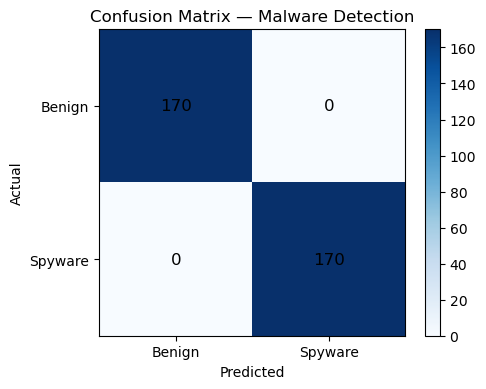

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues'); plt.colorbar()
plt.xticks([0,1],['Benign','Spyware']); plt.yticks([0,1],['Benign','Spyware'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Malware Detection")
for i in range(2):
    for j in range(2):
        plt.text(j,i,f"{cm[i,j]:,}",ha='center',va='center',fontsize=12)
plt.tight_layout(); plt.show()

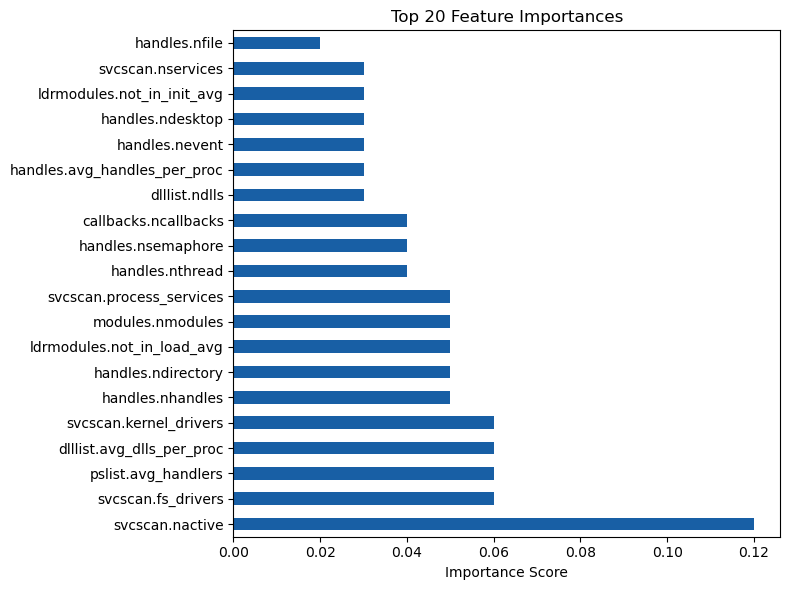

In [23]:
pd.Series(rf.feature_importances_, index=feature_cols).nlargest(20).plot(
    kind='barh', figsize=(8,6), color='#185FA5')
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout(); plt.show()